# Bibliotecas

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Leitura do dataframe

In [16]:
df = pd.read_excel('dados_modelo.xlsx')
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()

,autor,diâmetro_da_armadura_f_(mm),número_de_barras_em_uma_camada,espaçamento_entre_as_barras_(mm),resistência_à_tração_do_concreto_fctm_(mpa),cobrimento_c_(mm),distância_ao_centro_de_gravidade_da_armadura_d'_(mm),taxa_de_armadura_r,tensão_na_armadura_(mpa),tension_stiffening_(b),tensão_na_armadura_na_fissuração_do_concreto_(ssr),ss_-_bssr_(mpa),wexp_(mm),fib_model_code_2010,fib_model_code_2020,eurocode_2,nbr_6118_-_wk1_-_fissuração_estabilizada,nbr_6118_-_wk2_-_fissuração_não_estabilizada,clark_(1956),leonhardt_(1977),desayi;ganesan_(1985),oh;_kang_(1987),caldas_(1997),gergely_e_lutz_(1968),"_b__variável_e_<_0,6",equação_(15)_do_artigo_de_belarbi_e_hsu_(1994),beta_conforme_fields_e_bischoff_(2004),slip_de_yuan_et_al._(2025),slip_de_biscaia_e_soares_(2020)
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,4.120341,25.0,39.0,0.060724,231.811005,0.515850,90.135975,185.314362,0.16,0.125734,0.086159,0.125292,0.262468,0.157380,0.181006,0.296374,0.312684,0.185969,0.129998,0.241528,0.102130,0.149956,0.116566,0.109686,0.082007
1,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,304.251944,0.372710,90.135975,270.657365,0.23,0.176982,0.147127,0.176359,0.344489,0.271111,0.244363,0.447049,0.410398,0.256204,0.174746,0.317005,0.190783,0.204348,0.197288,0.193326,0.156266
2,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,314.282228,0.334820,90.135975,284.102901,0.24,0.184078,0.155568,0.183430,0.355846,0.289281,0.253135,0.467000,0.423928,0.265928,0.180941,0.327456,0.203058,0.212052,0.208041,0.205301,0.167096
3,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,363.319171,0.176945,90.135975,347.370061,0.27,0.218769,0.196838,0.217999,0.411368,0.386596,0.296022,0.562498,0.490072,0.313472,0.211232,0.378549,0.263069,0.250139,0.259368,0.265222,0.221958
4,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,459.164106,0.052750,90.135975,454.409433,0.35,0.286574,0.277502,0.285566,0.519888,0.617471,0.379848,0.742678,0.619355,0.406398,0.270437,0.478411,0.380363,0.311870,0.354810,0.388948,0.338382


In [17]:
colunas_modelos = ['fib_model_code_2010', 'fib_model_code_2020', 'eurocode_2',
                    'nbr_6118_-_wk1_-_fissuração_estabilizada',
                    'nbr_6118_-_wk2_-_fissuração_não_estabilizada', 'clark_(1956)',
                    'leonhardt_(1977)', 'desayi;ganesan_(1985)', 'oh;_kang_(1987)',
                    'caldas_(1997)', 'gergely_e_lutz_(1968)', '_b__variável_e_<_0,6',
                    'equação_(15)_do_artigo_de_belarbi_e_hsu_(1994)',
                    'beta_conforme_fields_e_bischoff_(2004)', 'slip_de_yuan_et_al._(2025)',
                    'slip_de_biscaia_e_soares_(2020)']

# Criando coluna de dados númericos

In [18]:
for coluna in colunas_modelos:
    df[f'wexp_(mm)/{coluna}'] = df['wexp_(mm)'] / df[coluna]
df.head()

,autor,diâmetro_da_armadura_f_(mm),número_de_barras_em_uma_camada,espaçamento_entre_as_barras_(mm),resistência_à_tração_do_concreto_fctm_(mpa),cobrimento_c_(mm),distância_ao_centro_de_gravidade_da_armadura_d'_(mm),taxa_de_armadura_r,tensão_na_armadura_(mpa),tension_stiffening_(b),tensão_na_armadura_na_fissuração_do_concreto_(ssr),ss_-_bssr_(mpa),wexp_(mm),fib_model_code_2010,fib_model_code_2020,eurocode_2,nbr_6118_-_wk1_-_fissuração_estabilizada,nbr_6118_-_wk2_-_fissuração_não_estabilizada,clark_(1956),leonhardt_(1977),desayi;ganesan_(1985),oh;_kang_(1987),caldas_(1997),gergely_e_lutz_(1968),"_b__variável_e_<_0,6",equação_(15)_do_artigo_de_belarbi_e_hsu_(1994),beta_conforme_fields_e_bischoff_(2004),slip_de_yuan_et_al._(2025),slip_de_biscaia_e_soares_(2020),wexp_(mm)/fib_model_code_2010,wexp_(mm)/fib_model_code_2020,wexp_(mm)/eurocode_2,wexp_(mm)/nbr_6118_-_wk1_-_fissuração_estabilizada,wexp_(mm)/nbr_6118_-_wk2_-_fissuração_não_estabilizada,wexp_(mm)/clark_(1956),wexp_(mm)/leonhardt_(1977),wexp_(mm)/desayi;ganesan_(1985),wexp_(mm)/oh;_kang_(1987),wexp_(mm)/caldas_(1997),wexp_(mm)/gergely_e_lutz_(1968),"wexp_(mm)/_b__variável_e_<_0,6",wexp_(mm)/equação_(15)_do_artigo_de_belarbi_e_hsu_(1994),wexp_(mm)/beta_conforme_fields_e_bischoff_(2004),wexp_(mm)/slip_de_yuan_et_al._(2025),wexp_(mm)/slip_de_biscaia_e_soares_(2020)
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,4.120341,25.0,39.0,0.060724,231.811005,0.515850,90.135975,185.314362,0.16,0.125734,0.086159,0.125292,0.262468,0.157380,0.181006,0.296374,0.312684,0.185969,0.129998,0.241528,0.102130,0.149956,0.116566,0.109686,0.082007,1.272527,1.857024,1.277020,0.609599,1.016650,0.883948,0.539858,0.511698,0.860358,1.230792,0.662449,1.566635,1.066978,1.372612,1.458715,1.951063
1,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,304.251944,0.372710,90.135975,270.657365,0.23,0.176982,0.147127,0.176359,0.344489,0.271111,0.244363,0.447049,0.410398,0.256204,0.174746,0.317005,0.190783,0.204348,0.197288,0.193326,0.156266,1.299566,1.563280,1.304155,0.667656,0.848361,0.941224,0.514485,0.560432,0.897723,1.316199,0.725540,1.205561,1.125531,1.165809,1.189699,1.471849
2,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,314.282228,0.334820,90.135975,284.102901,0.24,0.184078,0.155568,0.183430,0.355846,0.289281,0.253135,0.467000,0.423928,0.265928,0.180941,0.327456,0.203058,0.212052,0.208041,0.205301,0.167096,1.303795,1.542732,1.308399,0.674450,0.829643,0.948111,0.513919,0.566134,0.902498,1.326396,0.732923,1.181931,1.131798,1.153619,1.169016,1.436302
3,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,363.319171,0.176945,90.135975,347.370061,0.27,0.218769,0.196838,0.217999,0.411368,0.386596,0.296022,0.562498,0.490072,0.313472,0.211232,0.378549,0.263069,0.250139,0.259368,0.265222,0.221958,1.234178,1.371685,1.238536,0.656347,0.698404,0.912093,0.480002,0.550939,0.861321,1.278214,0.713251,1.026348,1.079398,1.040994,1.018015,1.216445
4,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,459.164106,0.052750,90.135975,454.409433,0.35,0.286574,0.277502,0.285566,0.519888,0.617471,0.379848,0.742678,0.619355,0.406398,0.270437,0.478411,0.380363,0.311870,0.354810,0.388948,0.338382,1.221324,1.261250,1.225637,0.673222,0.566828,0.921422,0.471267,0.565104,0.861225,1.294200,0.731588,0.920173,1.122261,0.986444,0.899863,1.034335


# Modelo a ser analisado

In [19]:
modelo = 'fib_model_code_2010'

### Criando coluna de erro absoluto

In [20]:
df['abs_error'] = df['wexp_(mm)'] - df[modelo]
df['abs_error'] = df['abs_error'].abs()

### Estátistica do modelo

In [21]:
df.describe()

,diâmetro_da_armadura_f_(mm),número_de_barras_em_uma_camada,espaçamento_entre_as_barras_(mm),resistência_à_tração_do_concreto_fctm_(mpa),cobrimento_c_(mm),distância_ao_centro_de_gravidade_da_armadura_d'_(mm),taxa_de_armadura_r,tensão_na_armadura_(mpa),tension_stiffening_(b),tensão_na_armadura_na_fissuração_do_concreto_(ssr),ss_-_bssr_(mpa),wexp_(mm),fib_model_code_2010,fib_model_code_2020,eurocode_2,nbr_6118_-_wk1_-_fissuração_estabilizada,nbr_6118_-_wk2_-_fissuração_não_estabilizada,clark_(1956),leonhardt_(1977),desayi;ganesan_(1985),oh;_kang_(1987),caldas_(1997),gergely_e_lutz_(1968),"_b__variável_e_<_0,6",equação_(15)_do_artigo_de_belarbi_e_hsu_(1994),beta_conforme_fields_e_bischoff_(2004),slip_de_yuan_et_al._(2025),slip_de_biscaia_e_soares_(2020),wexp_(mm)/fib_model_code_2010,wexp_(mm)/fib_model_code_2020,wexp_(mm)/eurocode_2,wexp_(mm)/nbr_6118_-_wk1_-_fissuração_estabilizada,wexp_(mm)/nbr_6118_-_wk2_-_fissuração_não_estabilizada,wexp_(mm)/clark_(1956),wexp_(mm)/leonhardt_(1977),wexp_(mm)/desayi;ganesan_(1985),wexp_(mm)/oh;_kang_(1987),wexp_(mm)/caldas_(1997),wexp_(mm)/gergely_e_lutz_(1968),"wexp_(mm)/_b__variável_e_<_0,6",wexp_(mm)/equação_(15)_do_artigo_de_belarbi_e_hsu_(1994),wexp_(mm)/beta_conforme_fields_e_bischoff_(2004),wexp_(mm)/slip_de_yuan_et_al._(2025),wexp_(mm)/slip_de_biscaia_e_soares_(2020),abs_error
count,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,331.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,331.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000
mean,17.910643,2.497076,63.710341,3.096916,32.647807,43.761988,0.050929,309.432666,0.360226,138.207936,261.124454,0.261491,0.214343,0.213672,0.222011,0.268977,0.318815,0.228499,0.338640,0.280726,0.212544,0.203577,0.279809,0.264761,0.272433,0.270149,0.274831,0.238946,1.399556,1.305933,1.247677,1.019624,1.024542,1.346931,0.868648,1.014646,1.322470,1.325821,0.951924,1.104957,0.999582,1.068349,1.054098,1.222901,0.070672
std,6.272794,1.365148,46.755024,0.514515,10.871746,12.119438,0.042848,91.257643,0.171707,96.501844,111.469814,0.114952,0.085954,0.083618,0.074902,0.079965,0.197194,0.106501,0.130679,0.103882,0.070822,0.080628,0.076917,0.118830,0.092722,0.112516,0.130288,0.109981,1.565848,0.522365,0.524637,0.469953,0.607797,0.735778,0.544022,0.431672,0.610760,0.386924,0.325986,0.526233,0.358435,0.516212,0.448545,0.566437,0.070066
min,9.520000,1.000000,12.000000,2.384602,12.800000,23.900000,0.007960,106.512655,0.000000,40.180305,4.520870,0.140000,0.007169,0.038597,0.045167,0.048418,0.039863,0.032681,0.033635,0.079566,0.049170,0.058045,0.096138,0.038597,0.067820,0.038597,0.053022,0.038113,0.640297,0.635122,0.494999,0.496635,0.220466,0.457119,0.414762,0.424392,0.645037,0.593979,0.475984,0.456402,0.410373,0.454974,0.391586,0.526293,0.000071
25%,12.000000,2.000000,40.000000,2.800000,25.000000,35.000000,0.017479,244.795079,0.242154,65.347574,185.752213,0.190000,0.152824,0.155081,0.166402,0.218387,0.191428,0.147475,0.254376,0.195888,0.160050,0.153722,0.220090,0.176353,0.209254,0.186595,0.191846,0.167970,0.940505,1.004902,0.928606,0.737804,0.626794,0.852952,0.620804,0.676506,0.902547,1.084861,0.724733,0.789928,0.760280,0.771923,0.753639,0.889115,0.024897
50%,16.000000,2.000000,46.000000,2.920876,30.000000,40.950000,0.044148,297.459578,0.387113,90.135975,241.740404,0.230000,0.204824,0.204996,0.215054,0.265757,0.271388,0.211976,0.319448,0.275114,0.209731,0.185627,0.281082,0.249898,0.258505,0.258586,0.254430,0.219838,1.202204,1.178255,1.150364,0.868107,0.886882,1.189766,0.731634,0.884967,1.132854,1.260876,0.871046,1.008202,0.942131,0.986592,0.950879,1.085943,0.050514
75%,20.000000,3.750000,69.800000,3.269000,40.000000,49.100000,0.065231,3

### Colocando em ordem de erro decrescente

In [22]:
df['Divisoes'] = pd.qcut(df['abs_error'], q=10, labels=False)
df = df.sort_values(by='abs_error', ascending=False)

### Salvando os dados

In [23]:
df.to_excel(f'estatistica_{modelo}.xlsx')
tabela = (f'estatistica_{modelo}.xlsx')
with pd.ExcelWriter(tabela, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df[df['Divisoes'] == 9].describe().to_excel(writer, sheet_name='35 maiores erros (9 div)')
    df[df['Divisoes'] == 8].describe().to_excel(writer, sheet_name='34 erros (8 div)')
    df[df['Divisoes'] == 7].describe().to_excel(writer, sheet_name='34 erros (7 div)')
    df[df['Divisoes'] == 6].describe().to_excel(writer, sheet_name='34 erros (6 div)')
    df[df['Divisoes'] == 5].describe().to_excel(writer, sheet_name='34 erros (5 div)')
    df[df['Divisoes'] == 4].describe().to_excel(writer, sheet_name='34 erros (4 div)')
    df[df['Divisoes'] == 3].describe().to_excel(writer, sheet_name='34 erros (3 div)')
    df[df['Divisoes'] == 2].describe().to_excel(writer, sheet_name='34 erros (2 div)')
    df[df['Divisoes'] == 1].describe().to_excel(writer, sheet_name='33 erros (1 div)')
    df[df['Divisoes'] == 0].describe().to_excel(writer, sheet_name='36 erros (0 div)')

# Alguns gráficos

### KDE

0.24939348085232294
0.009889437262667314


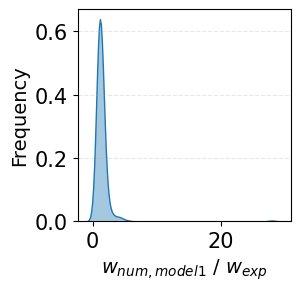

In [29]:
tips = df[f'wexp_(mm)/{modelo}'] 

# Tamanho da Figura em Centímetros
width_cm = 7
height_cm = 7
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

label_y_data = '$w_{num,model1}$ / $w_{exp}$'
tamanho_label = 14
cor_label = 'black'

# KDE
plt.figure(figsize=(width_in, height_in))

sns.kdeplot(data=tips, fill=True, alpha=0.4)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel(label_y_data, fontsize=tamanho_label, color=cor_label)
plt.ylabel('Frequency', fontsize=tamanho_label, color=cor_label)
plt.grid(axis='y', linestyle='--', alpha=0.3)
y_obse = df['wexp_(mm)']
y_pred = df[f'{modelo}']
print(r2_score(y_obse, y_pred))
print(mean_squared_error(y_obse, y_pred))
# plt.savefig('histograma_padrao.png', dpi=300)

### Scatterplot

In [ ]:
X_value = df['wexp_(mm)']
Y_value = df[modelo]

# Tamanho da Figura em Centímetros
width_cm = 18
height_cm = 12
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

# Título e Rótulos
label_x = '$w_{exp}$ (mm)'
label_y = 'Modelo'
tamanho_label = 14
cor_label = 'black'

# Configurações do Scatter Plot
tamanho_pontos = 30
cor_cmap = 'viridis'
alpha_transparencia = 0.7
cor_borda_ponto = 'black'
espessura_borda_ponto = 0.8

#Configurações da linha de regressão
cor_linha_regressao = 'red'
estilo_linha_regressao = '--'
espessura_linha_regressao = 1

#SCATTER PLOT SEM BARRA DE CORES
plt.figure(figsize=(width_in, height_in))
plt.scatter(X_value, Y_value,
                s=tamanho_pontos,
                c='blue',
                alpha=alpha_transparencia,
                edgecolors=cor_borda_ponto,
                linewidths=espessura_borda_ponto)

x_line = np.array([0, X_value.max()])
y_line = x_line
plt.plot(x_line, y_line,
        color=cor_linha_regressao,
        linestyle=estilo_linha_regressao,
        linewidth=espessura_linha_regressao,
        label='Linha de Regressão',
        zorder=1)

plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel(label_x, fontsize=tamanho_label, color=cor_label)
plt.ylabel(label_y, fontsize=tamanho_label, color=cor_label)
plt.grid(True, linestyle='--', alpha=0.3)



y1 = df['wexp (mm)']
x1 = df[modelo]
print(r2_score(y1, x1))
print(mean_squared_error(y1, x1))

plt.show()
#plt.savefig('scatter_plot_sem_legenda_linha_diagonal.png', dpi=300)

KeyError: 'wexp (mm)'